# 文件: chart_61_1.py

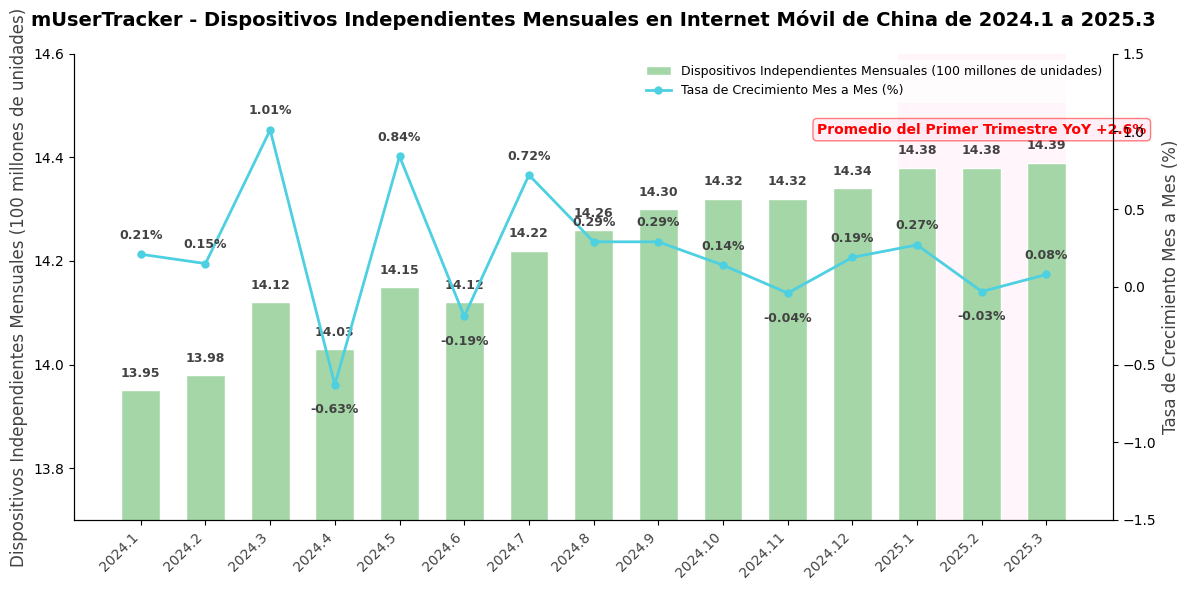

In [1]:
import matplotlib.pyplot as plt
import numpy as np

# Datos
meses = [
    "2024.1", "2024.2", "2024.3", "2024.4", "2024.5", 
    "2024.6", "2024.7", "2024.8", "2024.9", "2024.10", 
    "2024.11", "2024.12", "2025.1", "2025.2", "2025.3"
]
conteo_dispositivos = [13.95, 13.98, 14.12, 14.03, 14.15, 14.12, 14.22, 14.26, 14.30, 14.32, 14.32, 14.34, 14.38, 14.38, 14.39]
tasas_de_crecimiento = [0.21, 0.15, 1.01, -0.63, 0.84, -0.19, 0.72, 0.29, 0.29, 0.14, -0.04, 0.19, 0.27, -0.03, 0.08]

# Esquema de colores
color_barra = "#a5d6a7"
color_linea = "#4dd0e1"
color_destacado = "#ffe0f0"
color_texto = "#424242"

# Crear el gráfico
fig, ax1 = plt.subplots(figsize=(12, 6))
ax2 = ax1.twinx()

x = np.arange(len(meses))

# Gráfico de barras
barras = ax1.bar(
    x, conteo_dispositivos, color=color_barra, width=0.6,
    edgecolor="white", linewidth=1,
    label="Dispositivos Independientes Mensuales (100 millones de unidades)"
)

# Gráfico de línea
ax2.plot(
    x, tasas_de_crecimiento, color=color_linea, marker="o",
    linewidth=2, markersize=5, label="Tasa de Crecimiento Mes a Mes (%)"
)

# Rango de los ejes
ax1.set_ylim(13.7, 14.6)
ax2.set_ylim(-1.5, 1.5)

# Etiquetas de texto para el gráfico de barras (encima de las barras)
for i, barra in enumerate(barras):
    altura = barra.get_height()
    ax1.text(
        barra.get_x() + barra.get_width()/2,
        altura + 0.02,
        f"{altura:.2f}",
        ha="center", va="bottom",
        fontsize=9, color=color_texto,
        fontweight="bold"
    )

# Etiquetas de texto para el gráfico de línea (evitar superposición)
for i, valor in enumerate(tasas_de_crecimiento):
    desplazamiento_y = 0.08 if valor >= 0 else -0.12
    va = "bottom" if valor >= 0 else "top"
    ax2.text(
        i, valor + desplazamiento_y,
        f"{valor:.2f}%",
        ha="center", va=va,
        fontsize=9, color=color_texto,
        fontweight="bold"
    )

# Destacar el área del primer trimestre
inicio_q1 = meses.index("2025.1")
fin_q1 = meses.index("2025.3")
ax1.axvspan(inicio_q1 - 0.3, fin_q1 + 0.3, facecolor=color_destacado, alpha=0.3, zorder=0)
ax1.text(
    (inicio_q1 + fin_q1) / 2, max(conteo_dispositivos) + 0.05,
    "Promedio del Primer Trimestre YoY +2.6%", ha="center", va="bottom",
    fontsize=10, color="red", fontweight="bold",
    bbox=dict(boxstyle="round,pad=0.3", fc=color_destacado, ec="red", alpha=0.5)
)

# Eje X
ax1.set_xticks(x)
ax1.set_xticklabels(meses, rotation=45, ha="right", fontsize=10, color=color_texto)

# Etiquetas de los ejes Y
ax1.set_ylabel("Dispositivos Independientes Mensuales (100 millones de unidades)", fontsize=12, color=color_texto)
ax2.set_ylabel("Tasa de Crecimiento Mes a Mes (%)", fontsize=12, color=color_texto)

# Leyenda
lineas1, etiquetas1 = ax1.get_legend_handles_labels()
lineas2, etiquetas2 = ax2.get_legend_handles_labels()
ax1.legend(lineas1 + lineas2, etiquetas1 + etiquetas2, loc="upper right", fontsize=9, frameon=True, facecolor="white", edgecolor="white")

# Quitar bordes
ax1.spines["top"].set_visible(False)
ax2.spines["top"].set_visible(False)

# Título
ax1.set_title(
    "mUserTracker - Dispositivos Independientes Mensuales en Internet Móvil de China de 2024.1 a 2025.3",
    fontsize=14, fontweight="bold", pad=20
)

plt.tight_layout()
plt.show()

# 文件: chart_61_2.py

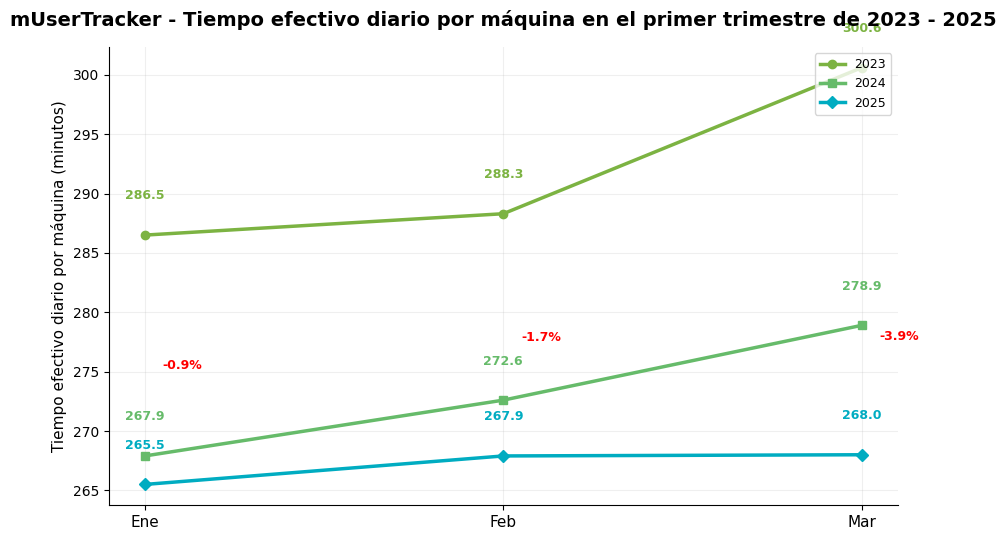

In [2]:
import matplotlib.pyplot as plt
import numpy as np

# -------------------- Definición de Datos --------------------
meses = ["Ene", "Feb", "Mar"]
años = ["2023", "2024", "2025"]

# Datos: [2023, 2024, 2025] (minutos)
datos = np.array([
    [286.5, 267.9, 265.5],  # Ene
    [288.3, 272.6, 267.9],  # Feb
    [300.6, 278.9, 268.0],  # Mar
])

# Mejora del estilo de color
colores = ["#7CB342", "#66BB6A", "#00ACC1"]  # Corresponde a 2023/2024/2025
marcadores = ["o", "s", "D"]

# -------------------- Crear el lienzo --------------------
fig, ax = plt.subplots(figsize=(9, 5.5))

# -------------------- Dibujar múltiples líneas --------------------
x = np.arange(len(meses))
for i in range(len(años)):
    y = datos[:, i]
    ax.plot(
        x, y, marker=marcadores[i], linewidth=2.5, 
        label=años[i], color=colores[i]
    )
    # Agregar etiquetas de datos
    for j, val in enumerate(y):
        ax.text(
            x[j], val + 3,
            f"{val}", ha='center', fontsize=9,
            color=colores[i], fontweight='bold'
        )

# -------------------- Etiquetas de tasa de crecimiento interanual (2024→2025) --------------------
for i in range(len(meses)):
    tasa = datos[i][2] - datos[i][1]
    tasa_pct = round((tasa / datos[i][1]) * 100, 1)
    color = "red" if tasa_pct < 0 else "green"
    ax.text(
        x[i] + 0.05, datos[i][2] + 10,
        f"{tasa_pct:+}%", color=color,
        fontsize=9, ha="left", va="center", fontweight="bold"
    )

# -------------------- Embellecer el gráfico --------------------
ax.set_xticks(x)
ax.set_xticklabels(meses, fontsize=11)
ax.set_ylabel("Tiempo efectivo diario por máquina (minutos)", fontsize=11)
ax.set_title("mUserTracker - Tiempo efectivo diario por máquina en el primer trimestre de 2023 - 2025", fontsize=14, fontweight="bold", pad=15)

# Líneas de cuadrícula
ax.grid(alpha=0.2)

# Leyenda
ax.legend(loc="upper right", fontsize=9, frameon=True)

# Eliminar bordes redundantes
for spine in ["top", "right"]:
    ax.spines[spine].set_visible(False)

plt.tight_layout()
plt.show()

# 文件: chart_61_3.py

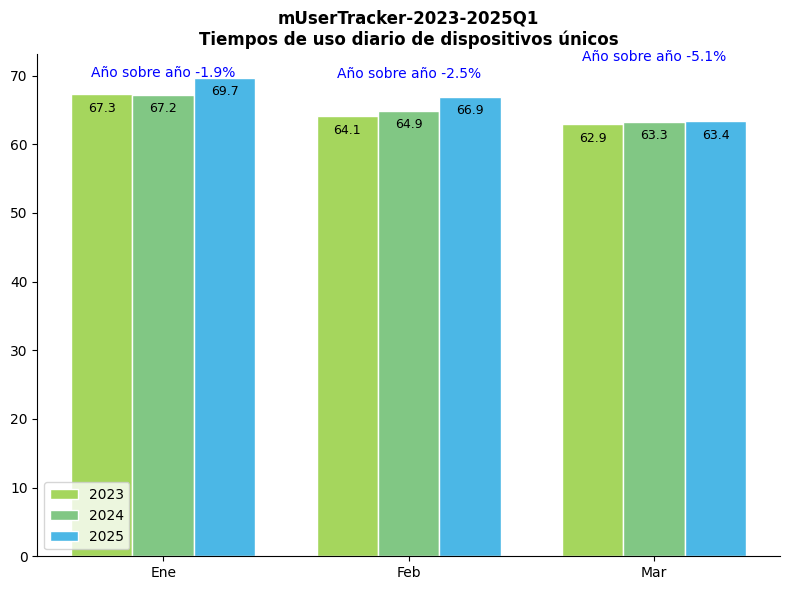

In [3]:
import matplotlib.pyplot as plt
import numpy as np

# Definición de datos
meses = ["Ene", "Feb", "Mar"]
años = ["2023", "2024", "2025"]
datos = [
    [67.3, 64.1, 62.9],
    [67.2, 64.9, 63.3],
    [69.7, 66.9, 63.4]
]
tazas_de_crecimiento = ["Año sobre año -1.9%", "Año sobre año -2.5%", "Año sobre año -5.1%"]
colores = ["#a5d65d", "#81c784", "#4bb7e6"]  # Coincidir con los colores del gráfico

# Crear un lienzo
fig, ax = plt.subplots(figsize=(8, 6))

# Dibujar un gráfico de barras agrupadas
x = np.arange(len(meses))
ancho_de_barra = 0.25
for i in range(3):
    ax.bar(x + i * ancho_de_barra, datos[i], width=ancho_de_barra, color=colores[i], label=años[i], edgecolor='white')
    # Agregar etiquetas de datos
    for j, val in enumerate(datos[i]):
        ax.text(x[j] + i * ancho_de_barra, val - 3, f'{val}', ha='center', va='bottom', fontsize=9)

# Agregar anotaciones año sobre año
for i in range(3):
    ax.text(x[i] + 1 * ancho_de_barra, max(datos[i]) + 2, tazas_de_crecimiento[i], ha='center', va='bottom', fontsize=10, color='blue')

# Emprolijar la configuración
ax.set_title("mUserTracker-2023-2025Q1\nTiempos de uso diario de dispositivos únicos", fontsize=12, fontweight='bold')
ax.set_xticks(x + ancho_de_barra)
ax.set_xticklabels(meses)
ax.legend()
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.show()